![image.png](https://i.imgur.com/a3uAqnb.png)

# 🎥 UCF101 Video Classification Using 3D ResNet - Homework Assignment

In this homework, you will fine tune a **3D ResNet model for video classification** to recognize human actions from short video clips. This project is designed to give you practical experience working with spatiotemporal data using deep learning.

## 📌 Project Overview
- **Task**: Classify human actions from video clips
- **Architecture**: 3D ResNet for video classification
- **Dataset**: UCF101 action recognition dataset
- **Goal**: Build an accurate classification model using PyTorch

## 📚 Learning Objectives
By completing this assignment, you will:
- Learn how to process and sample frames from video files
- Fine tune a 3D ResNet model using PyTorch
- Train and evaluate models on the UCF101 dataset
- Analyze model performance on real-world video data

## 📦 Dataset Details
- The **UCF101** dataset contains 13,320 training videos across 101 action categories
- Each video clip captures a single action performed by a human in various environments
- Videos are processed into fixed-length clips (e.g., 16 or 32 frames) for training

## 🏷️ Labels Representation
- Each video is labeled with a class index from `0` to `100`
- Example classes include:
  - `Basketball`
  - `Horse Riding`
  - `Ice Dancing`
  - `Playing Guitar`
  - `Volleyball Spiking`

## 🔗 Reference
Original dataset link: [UCF101 Kaggle Dataset](https://www.kaggle.com/datasets/pevogam/ucf101)


## 1️⃣ Initial Setup and Library Installation

**Task**: Set up the environment and install necessary libraries.

In [1]:
from IPython.display import clear_output

In [2]:
# Incase you run this notebook outside colab (where the libraries aren't already pre-installed)

# %pip install torch
# %pip install matplotlib
# %pip install scikit-learn
# %pip install pandas
# %pip install numpy
# %pip install opencv-python

clear_output()

## 2️⃣ Import Libraries and Configuration

**Task**: Import all necessary libraries and set up configuration parameters.

**Requirements**:
- Import PyTorch and 3D ResNet model
- Import data processing libraries (pandas, sklearn, cv2)
- Import visualization libraries
- Set random seeds for reproducibility
- Configure hyperparameters with reasonable values

In [3]:
import os
import cv2
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
import torch.nn.functional as F
import sklearn as sk


import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from torchvision.models.video import r3d_18
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

import kagglehub
from IPython.display import clear_output

In [4]:
torch.manual_seed(42)
np.random.seed(42)
sk.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

BATCH_SIZE = 8
LEARNING_RATE = 1e-4
NUM_EPOCHS = 10
FRAMES_PER_CLIP = 16
NUM_CLASSES = 101
VALIDATION_SPLIT = 0.15
TEST_SPLIT = 0.15

Using device: cuda


## 3️⃣ Data Loading and Exploration

**Task**: Download the UCF101 dataset and explore its structure.

**Requirements**:
- Download and load the dataset
- Display basic information about the data
- Load class mappings and video file paths
- Understand the dataset structure and labels

In [5]:
path = kagglehub.dataset_download("pevogam/ucf101")

print("Path to dataset files:", path)

100%|██████████| 6.49G/6.49G [02:45<00:00, 42.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/pevogam/ucf101/versions/1


In [6]:
# Load class name to index
classInd_txt = path + "/UCF101TrainTestSplits-RecognitionTask/ucfTrainTestlist/classInd.txt"
cls_df = pd.read_csv(classInd_txt, sep=" ", header=None,
                        names=["index", "class_name"])
cls_df.head()

,index,class_name
0,1,ApplyEyeMakeup
1,2,ApplyLipstick
2,3,Archery
3,4,BabyCrawling
4,5,BalanceBeam


In [7]:
# Crete class_to_idx and idx_to_class dictionaries.
class_to_idx = dict(zip(cls_df.class_name, cls_df.index))
idx_to_class = {idx:name for name, idx in class_to_idx.items()}

print(f"There are {len(class_to_idx)} classes.\n")
print(class_to_idx)
print()
print(idx_to_class)

There are 101 classes.

{'ApplyEyeMakeup': 0, 'ApplyLipstick': 1, 'Archery': 2, 'BabyCrawling': 3, 'BalanceBeam': 4, 'BandMarching': 5, 'BaseballPitch': 6, 'Basketball': 7, 'BasketballDunk': 8, 'BenchPress': 9, 'Biking': 10, 'Billiards': 11, 'BlowDryHair': 12, 'BlowingCandles': 13, 'BodyWeightSquats': 14, 'Bowling': 15, 'BoxingPunchingBag': 16, 'BoxingSpeedBag': 17, 'BreastStroke': 18, 'BrushingTeeth': 19, 'CleanAndJerk': 20, 'CliffDiving': 21, 'CricketBowling': 22, 'CricketShot': 23, 'CuttingInKitchen': 24, 'Diving': 25, 'Drumming': 26, 'Fencing': 27, 'FieldHockeyPenalty': 28, 'FloorGymnastics': 29, 'FrisbeeCatch': 30, 'FrontCrawl': 31, 'GolfSwing': 32, 'Haircut': 33, 'Hammering': 34, 'HammerThrow': 35, 'HandstandPushups': 36, 'HandstandWalking': 37, 'HeadMassage': 38, 'HighJump': 39, 'HorseRace': 40, 'HorseRiding': 41, 'HulaHoop': 42, 'IceDancing': 43, 'JavelinThrow': 44, 'JugglingBalls': 45, 'JumpingJack': 46, 'JumpRope': 47, 'Kayaking': 48, 'Knitting': 49, 'LongJump': 50, 'Lunges':

In [8]:
videos_root = path + "/UCF101/UCF-101"
paths_file = path + "/UCF101TrainTestSplits-RecognitionTask/ucfTrainTestlist/trainlist01.txt"

all_videos = []
all_labels = []

with open(paths_file, "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) != 2:
            continue
        rel_path, label_str = parts
        label = int(label_str) - 1
        full_path = os.path.join(videos_root, rel_path)
        if os.path.exists(full_path):
            all_videos.append(full_path)
            all_labels.append(label)

print(f"Total videos loaded: {len(all_videos)}")

Total videos loaded: 9537


## 4️⃣ Data Preprocessing & Dataset Creation & data showing

**Task**: Create custom dataset class and prepare data splits.

**Requirements**:
- Implement video reading and frame sampling
- Create custom PyTorch Dataset class
- Split data into train/validation/test sets
- Apply appropriate transformations
- Create data loaders for batch processing
- Visualize clips of a video
- Show a video

In [9]:
def read_video_opencv(video_path, frames_per_clip=16):
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Calculate frame indices to sample evenly
    indices = torch.linspace(0, total_frames - 1, frames_per_clip).long().tolist()

    for i in range(total_frames):
        ret, frame = cap.read()
        if not ret:
            break
        if i in indices:
            # Convert BGR to RGB
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)

    cap.release()

    # Pad if too short
    while len(frames) < frames_per_clip:
        frames.append(frames[-1])

    # Convert to tensor and permute dims to (T, C, H, W)
    frames_tensor = torch.stack([
        transforms.ToTensor()(frame) for frame in frames
    ])

    # Permute to (C, T, H, W)
    frames_tensor = frames_tensor.permute(1, 0, 2, 3)

    return frames_tensor

In [10]:
class UCF101Dataset(Dataset):
    def __init__(self, videos, labels, transform=None, frames_per_clip=16):
        self.videos = videos
        self.labels = labels
        self.transform = transform
        self.frames_per_clip = frames_per_clip

    def __len__(self):
        return len(self.videos)

    def __getitem__(self, idx):
        video_path = self.videos[idx]
        label = self.labels[idx]
        video_frames = read_video_opencv(video_path, self.frames_per_clip)
        T = video_frames.shape[1]

        if T >= self.frames_per_clip:
            indices = torch.linspace(0, T - 1, self.frames_per_clip).long()
            clip = video_frames[:, indices, :, :]
        else:
            pad = video_frames[:, -1:, :, :].repeat(1, self.frames_per_clip - T, 1, 1)
            clip = torch.cat([video_frames, pad], dim=1)

        if self.transform:
            clip = torch.stack([self.transform(frame) for frame in clip])

        return clip, label

In [11]:
train_videos, temp_videos, train_labels, temp_labels = train_test_split(
    all_videos, all_labels, test_size=0.3, stratify=all_labels
)

val_videos, test_videos, val_labels, test_labels = train_test_split(
    temp_videos, temp_labels, test_size=0.5, stratify=temp_labels
)

print("Train size:", len(train_videos), len(train_labels))
print("Train size:", len(val_videos), len(val_labels))
print("Test size:", len(test_videos), len(test_labels))

Train size: 6675 6675
Train size: 1431 1431
Test size: 1431 1431


In [12]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ConvertImageDtype(torch.float32),
])

train_dataset = UCF101Dataset(train_videos, train_labels, transform=transform, frames_per_clip=FRAMES_PER_CLIP)
val_dataset = UCF101Dataset(val_videos, val_labels, transform=transform, frames_per_clip=FRAMES_PER_CLIP)
test_dataset = UCF101Dataset(test_videos, test_labels, transform=transform, frames_per_clip=FRAMES_PER_CLIP)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True) # Shuffle it to train the model after validating.
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [13]:
# Checking dataloders shape
for video_batch, labels in train_loader:
    print("Batch shape:", video_batch.shape)
    print("Labels:", labels)
    break

sample_video, sample_label = train_dataset[0]
print(f"Sample video shape: {sample_video.shape}")
print(f"Sample label: {sample_label} ({idx_to_class[sample_label]})")

Batch shape: torch.Size([8, 3, 16, 128, 128])
Labels: tensor([39, 46,  0, 13, 58, 14, 20, 62])
Sample video shape: torch.Size([3, 16, 128, 128])
Sample label: 71 (PushUps)


In [14]:
def show_video_clip(tensor_clip, label='', fps=None):
    """
    Display a (C, T, H, W) tensor as an animation inline with a label.

    Parameters:
      tensor_clip (Tensor): A tensor of shape (C, T, H, W)
      label (str): Text label to display (e.g., class name)
      fps (int): Frames per second. If None, defaults to T (one second playback)
    """
    # Permute from (C, T, H, W) to (T, H, W, C)
    clip = tensor_clip.permute(1, 2, 3, 0).cpu().numpy()

    if fps is None:
        fps = clip.shape[0]  # Use T as default fps

    fig, ax = plt.subplots()
    ax.set_title(label)
    im = ax.imshow(clip[0])

    def update(frame_idx):
        im.set_array(clip[frame_idx])
        return [im]

    ani = animation.FuncAnimation(fig, update, frames=clip.shape[0], interval=1000 // fps, blit=True)
    plt.close(fig)

    video_html = ani.to_html5_video()
    video_html = video_html.replace("controls>", "controls autoplay muted>")
    return HTML(video_html)



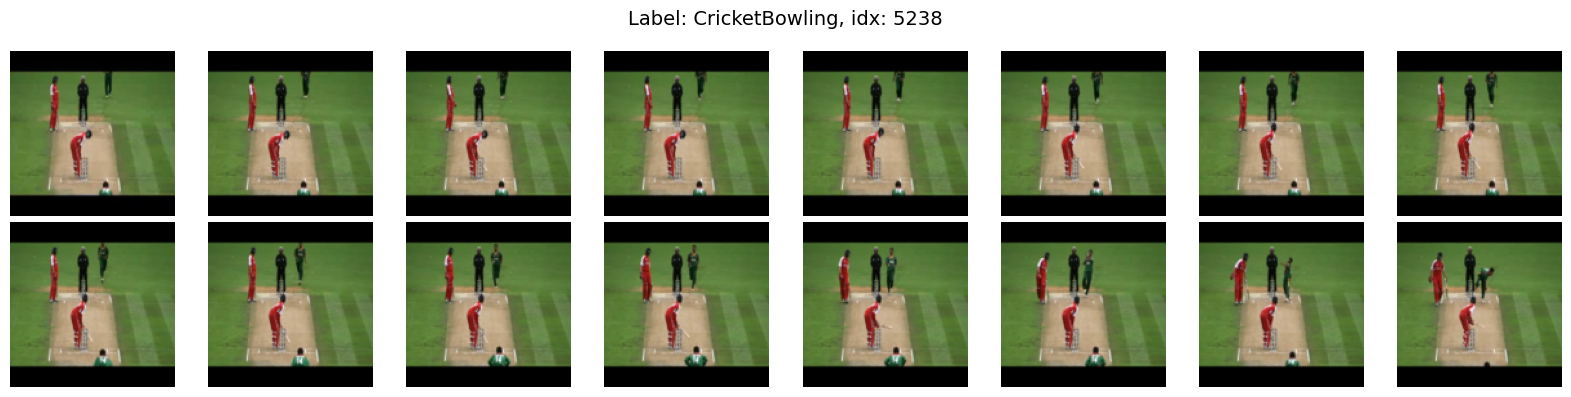

In [15]:
# Randomly get one video
idx = random.randint(0, len(train_dataset))
video, label = train_dataset[idx]  # video: (C, T, H, W)

label = idx_to_class[label] + f", idx: {idx}"

# Convert to numpy for visualization
video_np = video.permute(1, 2, 3, 0).numpy()  # (T, H, W, C)

# Plot frames
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle(f"Label: {label}", fontsize=14)

for i in range(16):
    row, col = divmod(i, 8)
    frame = video_np[i]
    axes[row][col].imshow(frame)
    axes[row][col].axis("off")

plt.tight_layout()
plt.show()


In [16]:
# idx = random.randint(0, len(train_dataset))

# Get one sample (clip)
video, label = train_dataset[idx]  # video: (C, T, H, W)

label = idx_to_class[label] + f", idx: {idx}"

# Show it
show_video_clip(video, label, 5)

## 5️⃣ Model Architecture and Fine-Tuning Setup

**Task**: Set up 3D ResNet model for fine-tuning and define training functions.

**Requirements**:
- Load pre-trained 3D ResNet model
- Modify final layer for UCF101 classes
- Define training and evaluation functions
- Implement metrics calculation

In [17]:
def build_model(num_classes):
    model = r3d_18(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def compute_metrics(preds, labels, num_classes):
    preds = preds.cpu()
    labels = labels.cpu()
    pred_labels = preds.argmax(dim=1)

    accuracy = (pred_labels == labels).float().mean().item() * 100
    precision = precision_score(labels, pred_labels, average='macro', zero_division=0) * 100
    recall = recall_score(labels, pred_labels, average='macro', zero_division=0) * 100
    f1 = f1_score(labels, pred_labels, average='macro', zero_division=0) * 100
    return accuracy, precision, recall, f1

In [18]:
model = build_model(NUM_CLASSES).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

print(f"Model loaded on {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=R3D_18_Weights.KINETICS400_V1`. You can also use `weights=R3D_18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth
100%|██████████| 127M/127M [00:00<00:00, 159MB/s]


Model loaded on cuda
Total parameters: 33,218,085


## 6️⃣ Training and Validation Functions

**Task**: Implement comprehensive training and validation loops.

**Requirements**:
- Define training loop with gradient computation
- Implement validation loop with metrics tracking
- Monitor training progress with appropriate metrics

In [22]:
def train_one_epoch(model, train_loader, optimizer, criterion, device, num_classes):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    loop = tqdm(train_loader, desc="Training", leave=False)
    for videos, labels in loop:
        videos = videos.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(videos)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        all_preds.append(outputs.detach())
        all_labels.append(labels.detach())



    preds = torch.cat(all_preds)
    labels = torch.cat(all_labels)
    acc, precision, recall, f1 = compute_metrics(preds, labels, num_classes)

    return total_loss / len(train_loader), {
        "accuracy": acc, "precision": precision, "recall": recall, "f1": f1
    }

In [23]:
@torch.no_grad()
def evaluate(model, val_loader, criterion, device, num_classes):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    loop = tqdm(val_loader, desc="Validating", leave=False)
    for videos, labels in loop:
        videos = videos.to(device)
        labels = labels.to(device)

        outputs = model(videos)
        loss = criterion(outputs, labels)

        total_loss += loss.item()
        all_preds.append(outputs)
        all_labels.append(labels)


    preds = torch.cat(all_preds)
    labels = torch.cat(all_labels)
    acc, precision, recall, f1 = compute_metrics(preds, labels, num_classes)

    return total_loss / len(val_loader), {
        "accuracy": acc, "precision": precision, "recall": recall, "f1": f1
    }

## 7️⃣ Training Loop with Validation

**Task**: Execute the complete training process with validation monitoring.

**Requirements**:
- Train model for specified epochs
- Track training and validation metrics
- Save best model based on validation performance
- Display training progress

In [24]:
train_losses = []
val_losses = []
best_val_acc = 0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    train_loss, train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device, NUM_CLASSES)
    train_losses.append(train_loss)

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_metrics['accuracy']:.2f}% | "
          f"P: {train_metrics['precision']:.2f} | R: {train_metrics['recall']:.2f} | F1: {train_metrics['f1']:.2f}")

    val_loss, val_metrics = evaluate(model, val_loader, criterion, device, NUM_CLASSES)
    val_losses.append(val_loss)

    print(f"Val Loss: {val_loss:.4f} | Acc: {val_metrics['accuracy']:.2f}% | "
          f"P: {val_metrics['precision']:.2f} | R: {val_metrics['recall']:.2f} | F1: {val_metrics['f1']:.2f}")

    if val_metrics['accuracy'] > best_val_acc:
        best_val_acc = val_metrics['accuracy']
        torch.save(model.state_dict(), 'best_video_model.pth')


Epoch 1/10


Training:   0%|          | 0/835 [00:00<?, ?it/s]

Train Loss: 0.0738 | Acc: 48.75% | P: 35.60 | R: 42.44 | F1: 34.59


Validating:   0%|          | 0/179 [00:00<?, ?it/s]

Val Loss: 0.3012 | Acc: 48.12% | P: 40.50 | R: 45.04 | F1: 38.91

Epoch 2/10


...

Val Loss: 0.1525 | Acc: 71.88% | P: 61.77 | R: 66.08 | F1: 61.37

Epoch 10/10


Training:   0%|          | 0/835 [00:00<?, ?it/s]

Train Loss: 0.0402 | Acc: 82.50% | P: 75.62 | R: 76.91 | F1: 74.35


Validating:   0%|          | 0/179 [00:00<?, ?it/s]

Val Loss: 0.1437 | Acc: 78.12% | P: 72.63 | R: 76.28 | F1: 72.25


## 8️⃣ Model Evaluation and Testing

**Task**: Evaluate the trained model on the test set and calculate classification metrics.

**Requirements**:
- Load best model for testing
- Make predictions on test set
- Calculate comprehensive classification metrics
- Analyze model performance

In [25]:
model.load_state_dict(torch.load('best_video_model.pth'))
test_loss, test_metrics = evaluate(model, test_loader, criterion, device, NUM_CLASSES)

print("="*50)
print("FINAL TEST RESULTS:")
print("="*50)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_metrics['accuracy']:.2f}%")
print(f"Test Precision: {test_metrics['precision']:.2f}%")
print(f"Test Recall: {test_metrics['recall']:.2f}%")
print(f"Test F1-Score: {test_metrics['f1']:.2f}%")

Validating:   0%|          | 0/179 [00:00<?, ?it/s]

FINAL TEST RESULTS:
Test Loss: 0.1447
Test Accuracy: 74.37%
Test Precision: 64.50%
Test Recall: 71.38%
Test F1-Score: 65.75%


## 9️⃣ Visualization and Analysis

**Task**: Create visualizations to analyze model performance and training progress.

**Requirements**:
- Plot training and validation loss curves
- Display sample predictions with confidence scores
- Analyze model performance across different classes

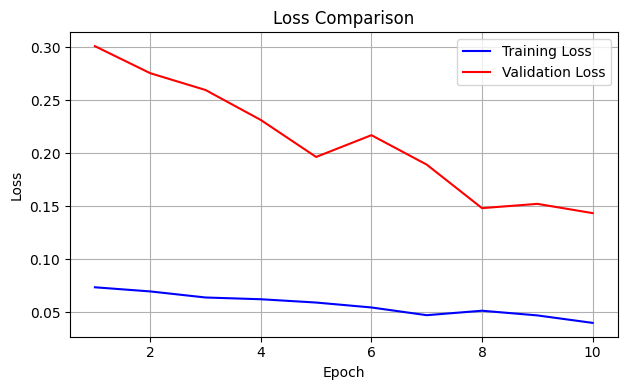

In [28]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 2)
epochs = range(1, len(train_losses) + 1)
plt.plot(epochs, train_losses, 'b-', label='Training Loss')
plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Comparison')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [29]:
model.eval()
sample_predictions = []

with torch.no_grad():
    for i in range(3):
        video, true_label = test_dataset[i]
        video_batch = video.unsqueeze(0).to(device)

        output = model(video_batch)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
        predicted_label = torch.argmax(probabilities).item()
        confidence = probabilities[predicted_label].item()

        sample_predictions.append({
            'true_label': idx_to_class[true_label],
            'predicted_label': idx_to_class[predicted_label],
            'confidence': confidence,
            'correct': true_label == predicted_label
        })

for i, pred in enumerate(sample_predictions):
    status = "✓" if pred['correct'] else "✗"
    print(f"Sample {i+1}: {status}")
    print(f"  True: {pred['true_label']}")
    print(f"  Predicted: {pred['predicted_label']} ({pred['confidence']:.2%} confidence)")
    print()

Sample 1: ✓
  True: PoleVault
  Predicted: PoleVault (59.35% confidence)

Sample 2: ✓
  True: IceDancing
  Predicted: IceDancing (91.66% confidence)

Sample 3: ✓
  True: BoxingPunchingBag
  Predicted: BoxingPunchingBag (99.79% confidence)



## 📝 Evaluation Criteria

Your homework will be evaluated based on:

1. **Implementation Correctness (50%)**
   - Proper 3D ResNet model setup and fine-tuning
   - Correct video data preprocessing and dataset implementation
   - Working training loop with validation
   - Appropriate loss function and optimizer usage

2. **Model Performance (25%)**
   - Reasonable classification metrics (Accuracy, Precision, Recall, F1)
   - Convergence during training
   - Generalization to test set

3. **Code Quality (25%)**
   - Clean, readable code with proper structure
   - Efficient video processing implementation
   - Good coding practices and documentation

# Created by: Hassan Alsayhah